#librarys importing

In [129]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns


# 1️⃣ Load dataset

In [130]:
data = pd.read_csv("/content/diabetes.csv")

###1.	Data Inspection

In [131]:
def data_diagnostic(df):
        print("#"*50)
        print(df.info())
        print("#"*50)
        print("The number of total rows  {x: .0f} ".format(x=df.shape[0]))
        print("The number of total variables {x: .0f} ".format(x=df.shape[1]))
        print("The variables names {x:} ".format(x=list(df.columns.values)))

        column_headers =list(df.columns.values)
        qualitative_columns = [col for col in column_headers if df[col].dtype=="object"]
        quantitative_columns = [col for col in column_headers if df[col].dtype in ['int64', 'float64']]

        print("The qualitative variables {x:} ".format(x=qualitative_columns))
        print("The quantitative variables {x:} ".format(x=quantitative_columns))
        print("#"*50)
        print("Total number missing value {x:} ".format(x=df.isnull().sum()))
        print("#"*50)
data_diagnostic(data)

##################################################
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
##################################################
The number of total rows   768 
The number of total variables  9 
The variables names ['Pregnancies', 'Glucose', 'BloodPressure', 'Sk

In [132]:
data.shape

(768, 9)

In [133]:
data.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


#Heatmap

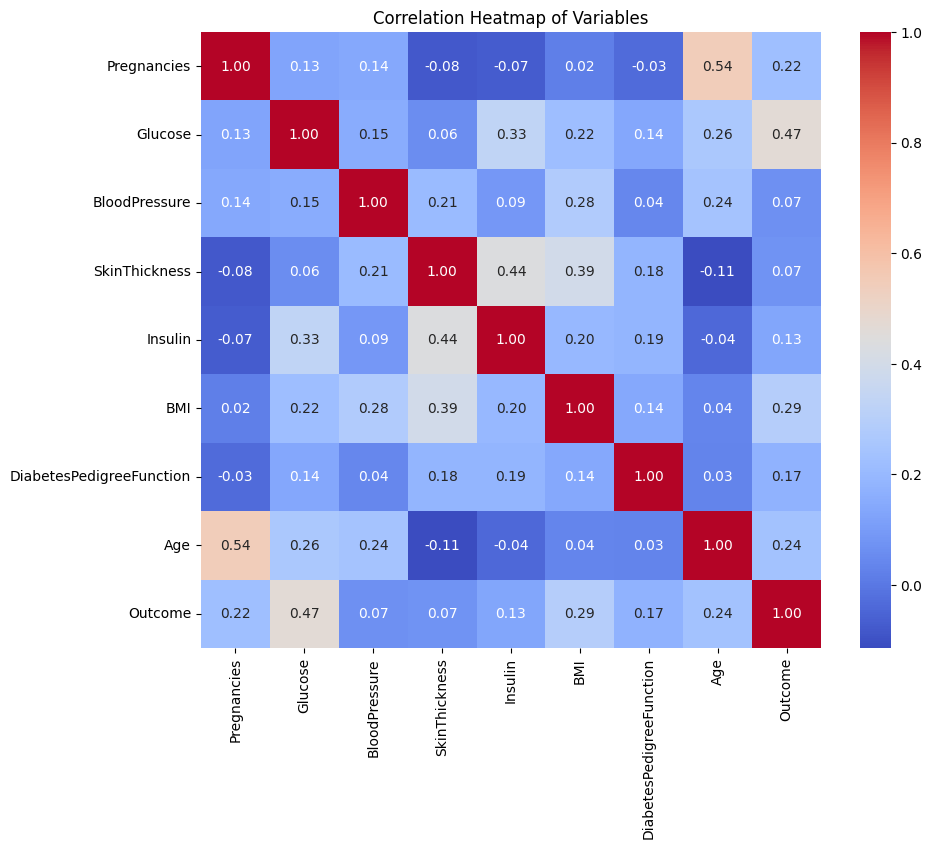

In [134]:
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Variables')
plt.show()

# Features and target

In [135]:
X = data.drop("Outcome", axis=1)
y = data["Outcome"]


# Split data

In [136]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


# 2️⃣ Train Logistic Regression model

In [137]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

# 3️⃣ Predict probability for one patient (first in test set)

In [138]:
p_diabetes = model.predict_proba(X_test.iloc[[0]])[0][1]

# Expected utilities

In [139]:
EU_treatment = p_diabetes * 0.9 + (1 - p_diabetes) * 0.6
EU_monitoring = p_diabetes * 0.3 + (1 - p_diabetes) * 0.95

print("Probability of diabetes:", round(p_diabetes, 3))
print("Expected Utility (Treatment):", round(EU_treatment, 3))
print("Expected Utility (Monitoring):", round(EU_monitoring, 3))


Probability of diabetes: 0.267
Expected Utility (Treatment): 0.68
Expected Utility (Monitoring): 0.777


# 4️⃣ Visualization 1: Distribution of predicted probabilities

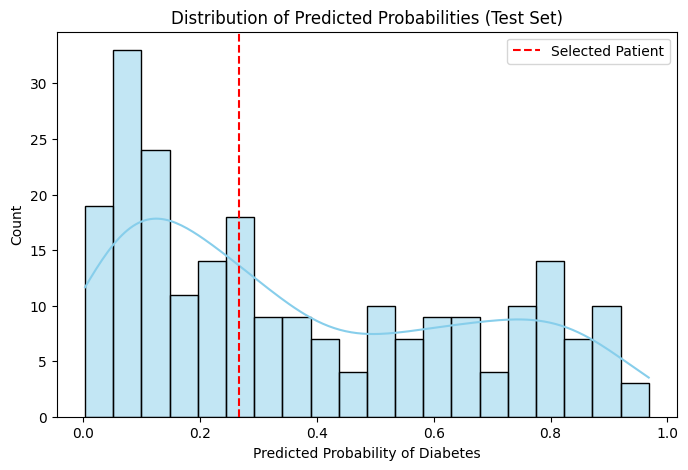

In [140]:
y_prob = model.predict_proba(X_test)[:,1]

plt.figure(figsize=(8,5))
sns.histplot(y_prob, bins=20, kde=True, color='skyblue')
plt.axvline(p_diabetes, color='red', linestyle='--', label="Selected Patient")
plt.xlabel("Predicted Probability of Diabetes")
plt.ylabel("Count")
plt.title("Distribution of Predicted Probabilities (Test Set)")
plt.legend()
plt.show()


### Interpretation of the "Distribution of Predicted Probabilities" Chart

This histogram displays the distribution of predicted probabilities of having diabetes for all patients in the test set. Here's what we can infer from it:

*   **Shape of the Distribution:** The histogram shows the frequency of different probability ranges. A high bar indicates that many patients have a predicted probability within that range. Ideally, for a well-performing model, we might expect a bimodal distribution with peaks near 0 (for non-diabetic patients) and near 1 (for diabetic patients), although this varies depending on the dataset and model.

*   **Model Confidence:** The spread of the distribution indicates the model's confidence. A narrow distribution around low or high probabilities suggests the model is often confident in its predictions. A wide, flat distribution might indicate more uncertainty.

*   **Red Dashed Line ("Selected Patient"):** The red dashed line marks the predicted probability of diabetes (`p_diabetes`) for the specific patient evaluated previously (the first patient in the test set). In this case, `p_diabetes` is 0.267. This line shows where this particular patient's probability falls within the overall distribution of probabilities predicted for the entire test set. It helps to contextualize the individual prediction against the model's general behavior.

*   **Decision Thresholds (Implicit):** While not explicitly shown, decision thresholds (e.g., classifying as 'diabetic' if probability > 0.5) would divide this distribution, and we can observe how many patients fall above or below such a threshold.

# 5️⃣ Visualization 2: Bar chart of Expected Utilities

/tmp/ipython-input-1434065512.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=utilities, palette="pastel")


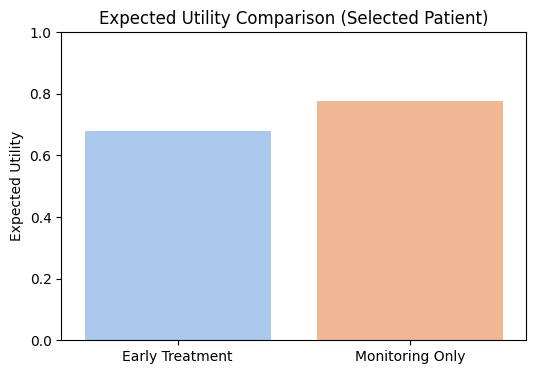

In [141]:
plt.figure(figsize=(6,4))
utilities = [EU_treatment, EU_monitoring]
labels = ['Early Treatment', 'Monitoring Only']
sns.barplot(x=labels, y=utilities, palette="pastel")
plt.ylabel("Expected Utility")
plt.title("Expected Utility Comparison (Selected Patient)")
plt.ylim(0,1)
plt.show()


### Interpretation of the "Bar chart of Expected Utilities"

This bar chart visually compares the expected utility of two different decision strategies for the selected patient: 'Early Treatment' and 'Monitoring Only'.

*   **Expected Utility (EU):** In decision theory, expected utility quantifies the overall desirability of a decision, considering the probabilities of different outcomes and the utility (value or satisfaction) associated with each outcome. A higher expected utility indicates a more favorable decision.

*   **Bars Representation:** Each bar in the chart represents the calculated expected utility for a specific decision. For the selected patient:
    *   **'Early Treatment' (EU_treatment):** This bar shows the expected utility if the patient undergoes early treatment. Its value is 0.680.
    *   **'Monitoring Only' (EU_monitoring):** This bar shows the expected utility if the patient is only monitored. Its value is 0.777.

*   **Decision Recommendation:** By comparing the heights of the bars, we can see which decision yields a higher expected utility for this particular patient. In this case, 'Monitoring Only' has a higher expected utility (0.777) compared to 'Early Treatment' (0.680).

*   **Conclusion:** Based on this chart, for the patient with a predicted diabetes probability of 0.267, the model recommends 'Monitoring Only' as the strategy that maximizes expected utility under the given utility values.

# 6️⃣ Visualization 3: ROC Curve for model performance

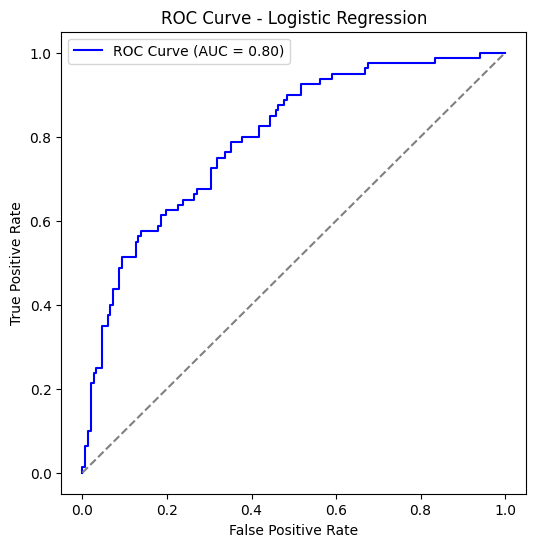

In [142]:
y_test_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)
auc_score = roc_auc_score(y_test, y_test_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()


### Interpretation of the "ROC Curve for Model Performance"

This ROC (Receiver Operating Characteristic) curve is a graphical plot that illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied. It's a fundamental tool for evaluating the performance of classification models.

*   **X-axis (False Positive Rate - FPR):** This represents the proportion of negative instances that are incorrectly classified as positive. It's calculated as `FP / (FP + TN)`.

*   **Y-axis (True Positive Rate - TPR, or Recall/Sensitivity):** This represents the proportion of positive instances that are correctly classified as positive. It's calculated as `TP / (TP + FN)`.

*   **The Curve (Blue Line):** The blue line on the plot is the ROC curve itself. Each point on the ROC curve represents a (FPR, TPR) pair corresponding to a particular classification threshold. Moving along the curve involves changing the threshold at which the model classifies a patient as having diabetes.

    *   A curve that bends towards the top-left corner indicates better performance. This is because it means the model achieves a high True Positive Rate (correctly identifies positives) while maintaining a low False Positive Rate (incorrectly classifies negatives).

*   **Diagonal Dashed Line (Gray):** This represents a random classifier (or a classifier that performs no better than random guessing). A model whose ROC curve falls on or below this line is considered to have poor discriminatory power.

*   **AUC (Area Under the Curve):** The AUC score, displayed in the legend (e.g., `AUC = 0.80`), quantifies the overall performance of the classifier across all possible classification thresholds.

    *   An AUC of 1.0 indicates a perfect classifier (100% TPR, 0% FPR).
    *   An AUC of 0.5 suggests a classifier that performs no better than random.
    *   An AUC between 0.5 and 1.0 indicates how well the model distinguishes between positive and negative classes. A higher AUC generally means a better model.

*   **Conclusion:** In this case, an AUC of 0.80 suggests that the Logistic Regression model has good discriminatory power in distinguishing between patients with and without diabetes. The curve is well above the random classifier line, indicating that the model is performing significantly better than chance.

# 7️⃣ Decision recommendation for all patients in test set
# Calculate expected utilities for all patients

In [143]:
EU_treatment_all = y_test_prob * 0.9 + (1 - y_test_prob) * 0.6
EU_monitoring_all = y_test_prob * 0.3 + (1 - y_test_prob) * 0.95


# Decision: choose option with higher expected utility

In [144]:

decision = ['Monitoring' if EU_monitoring_all[i] > EU_treatment_all[i] else 'Treatment'
            for i in range(len(y_test_prob))]


# Add results to a DataFrame

In [145]:
results_df = X_test.copy()
results_df['Actual'] = y_test.values
results_df['Predicted_Prob'] = y_test_prob
results_df['EU_Treatment'] = EU_treatment_all
results_df['EU_Monitoring'] = EU_monitoring_all
results_df['Decision'] = decision

print("\nSample of Decision Recommendations for Test Set:")
print(results_df.head())



Sample of Decision Recommendations for Test Set:
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
668            6       98             58             33      190  34.0   
324            2      112             75             32        0  35.7   
624            2      108             64              0        0  30.8   
690            8      107             80              0        0  24.6   
473            7      136             90              0        0  29.9   

     DiabetesPedigreeFunction  Age  Actual  Predicted_Prob  EU_Treatment  \
668                     0.430   43       0        0.266577      0.679973   
324                     0.148   21       0        0.190146      0.657044   
624                     0.158   21       0        0.123599      0.637080   
690                     0.856   34       0        0.145651      0.643695   
473                     0.210   50       0        0.504579      0.751374   

     EU_Monitoring    Decision  
668       0.776

# 8️⃣ Visualization 4: Decision count

/tmp/ipython-input-1872711869.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Decision', data=results_df, palette='pastel')


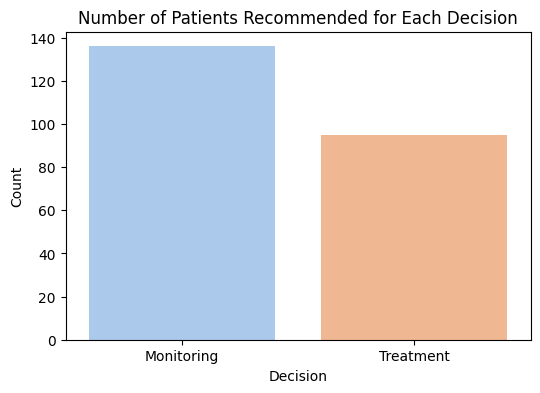

In [146]:
plt.figure(figsize=(6,4))
sns.countplot(x='Decision', data=results_df, palette='pastel')
plt.title("Number of Patients Recommended for Each Decision")
plt.ylabel("Count")
plt.show()


### Interpretation of the "Decision Count" Chart

This bar chart visualizes the distribution of the recommended decisions ('Early Treatment' or 'Monitoring Only') for all patients in the test set, based on the expected utility calculations.

*   **Purpose:** The chart provides an overview of how many patients, according to our decision model, should receive 'Early Treatment' versus 'Monitoring Only'. This helps in understanding the overall impact and leanings of the decision-making process.

*   **Bars Representation:**
    *   One bar represents the count of patients for whom 'Early Treatment' was the recommended decision (i.e., `EU_treatment > EU_monitoring`).
    *   The other bar represents the count of patients for whom 'Monitoring Only' was the recommended decision (i.e., `EU_monitoring > EU_treatment`).

*   **Insights:** By observing the heights of these bars, we can quickly grasp the proportion of the test population that falls into each recommendation category. For example, if one bar is significantly taller than the other, it indicates that the model favors that particular decision for a larger number of patients under the given utility assumptions.

*   **Context:** This chart is a summary of the `Decision` column in the `results_df` DataFrame, providing a high-level view of the personalized recommendations generated by combining the predictive model's probabilities with the defined utility functions.